In [1]:
import tensorflow as tf 
import numpy as np
import pyvista as pv

### testing tf gradient functions

In [16]:
import tensorflow as tf

coords = tf.constant([[1.0, 2.0, 3.0],[4.0, 5.0, 6.0]], dtype=tf.float32)  # [1, 3]

def f(coords):
    x, y, z = tf.unstack(coords, axis=-1)
    return tf.stack([x**2 + y + z, tf.sin(x*y*z)], axis=-1)  # [1, 2]

with tf.GradientTape() as tape2:
    tape2.watch(coords)
    with tf.GradientTape() as tape1:
        tape1.watch(coords)
        out = f(coords)
        print(out)
    grad = tape1.batch_jacobian(out, coords)  # should be [1, 2, 1, 3]
    print("Jacobian1:" ,grad)
# grad2 = tape2.batch_jacobian(grad, coords)
# print("Jacobian2:",grad2)
    split = tf.unstack(grad, axis=-1)
    print(split)
grad2 = tape2.batch_jacobian(split[0], coords)
print("Jacobian2:", grad2)

tf.Tensor(
[[ 6.         -0.2794155 ]
 [27.          0.58061117]], shape=(2, 2), dtype=float32)
Jacobian1: tf.Tensor(
[[[ 2.         1.         1.       ]
  [ 5.7610216  2.8805108  1.9203405]]

 [[ 8.         1.         1.       ]
  [24.42543   19.540344  16.283619 ]]], shape=(2, 2, 3), dtype=float32)
[<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 2.       ,  5.7610216],
       [ 8.       , 24.42543  ]], dtype=float32)>, <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 1.       ,  2.8805108],
       [ 1.       , 19.540344 ]], dtype=float32)>, <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 1.       ,  1.9203405],
       [ 1.       , 16.283619 ]], dtype=float32)>]


2025-11-07 18:12:12.370111: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Jacobian2: tf.Tensor(
[[[   2.           0.           0.       ]
  [  10.058958     7.90999      5.2733264]]

 [[   2.           0.           0.       ]
  [-522.55005   -413.15497   -344.2958   ]]], shape=(2, 2, 3), dtype=float32)


2025-11-07 18:12:12.624655: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [14]:
split = tf.unstack(grad, axis=-1)
print(split)
grad2 = tape2.batch_jacobian(split[0], coords)
print(grad2)

[<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 2.       ,  5.7610216],
       [ 8.       , 24.42543  ]], dtype=float32)>, <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 1.       ,  2.8805108],
       [ 1.       , 19.540344 ]], dtype=float32)>, <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 1.       ,  1.9203405],
       [ 1.       , 16.283619 ]], dtype=float32)>]
tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]]], shape=(2, 2, 3), dtype=float32)


2025-11-07 18:11:05.008178: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [ ]:
class TransientNavierStokesLayer(Layer):

    def __init__(self, n_outputs, activation, inverse_pca_layer, rho, mu, timestep):
        super().__init__()
        self.concat = Concatenate()
        self.graph_conv = ChebConv(n_outputs, activation=activation, kernel_initializer='he_normal')
        self.ipca_layer = inverse_pca_layer
        self.timestep = timestep
        self.rho = rho
        self.mu = mu

    def call(self, inputs):
        coords, feature_maps, adjacency = inputs

        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(coords)
            with tf.GradientTape() as tape1:
                tape1.watch(coords)
                cfd_input = tf.concat([coords, feature_maps], axis=-1)
                res = ChebConv(self.n_outputs, activation=self.out_activation)([cfd_input, adjacency])
                out_pca_features = Add(name=f'res_{out_index}')([out_features, res])
                out_features = InversePca(name=f'res_ipca_{out_index}', **self.pca_args)(out_features)

            first_diff = tape1.batch_jacobian(out_features, coords) # [N, 400, 3]

            n_nodes = coords.shape[-2] # N
            n_fields = 4 
            n_timesteps = out_features.shape[-1] // n_fields # 100

            # Need to check reshaping and make sure it's the right way
            out_features_reshaped = tf.reshape(out_features, [n_nodes,n_timesteps, n_fields]) # [N,100,4]
            first_diff = tf.reshape(first_diff, [n_nodes,n_timesteps, n_fields,3]) # [N, 100,4, 3]

            # Extract fields
            _,u,v,w = tf.unstack(out_features_reshaped, axis=-1)# [N, 100]

            # Extract 1st spatial derivatives
            first_diff_split = tf.unstack(first_diff, axis=-2)  # [p_diff, u_diff, v_diff, w_diff]
            p_x, p_y, p_z = tf.unstack(first_diff_split[0], axis=-1) # [N,100]
            u_x, u_y, u_z = tf.unstack(first_diff_split[1], axis=-1)
            v_x, v_y, v_z = tf.unstack(first_diff_split[2], axis=-1)
            w_x, w_y, w_z = tf.unstack(first_diff_split[3], axis=-1)

        # Extract 2nd spatial derivatives
        u_xx,_,_ = tf.unstack(tape2.batch_jacobian(u_x, coords), axis=-1)# ([N,100], [N,3]) --> [N,100,3] --> [N,100]
        _,v_yy,_ = tf.unstack(tape2.batch_jacobian(v_y, coords), axis=-1)
        _,_,w_zz = tf.unstack(tape2.batch_jacobian(w_z, coords), axis=-1)

        # Extract temporal derivatives
        u_t = compute_finite_difference(u, axis=-1, delta=self.timestep)# [N, 100]
        v_t = compute_finite_difference(v, axis=-1, delta=self.timestep)
        w_t = compute_finite_difference(w, axis=-1, delta=self.timestep)

        # Momentum residuals
        mom_x = self.rho * u_t + self.rho * (u * u_x + v * u_y + w * u_z) + p_x - self.mu * u_xx
        mom_y = self.rho * v_t + self.rho * (u * v_x + v * v_y + w * v_z) + p_y - self.mu * v_yy
        mom_z = self.rho * w_t + self.rho * (u * w_x + v * w_y + w * w_z) + p_z - self.mu * w_zz

        # Continuity residual
        continuity = u_x + v_y + w_z
                
        cfd_residual = mom_x + mom_y + mom_z + continuity

        return out_pca_features, out_features, cfd_residual


class SteadyNavierStokesLayer(Layer):

    def __init__(self, n_outputs, activation, inverse_pca_layer, rho, mu, timestep):
        super().__init__()
        self.concat = Concatenate()
        self.graph_conv = ChebConv(n_outputs, activation=activation, kernel_initializer='he_normal')
        self.ipca_layer = inverse_pca_layer
        self.timestep = timestep
        self.rho = rho
        self.mu = mu

    def call(self, inputs):
        coords, feature_maps, adjacency = inputs

        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(coords)
            with tf.GradientTape() as tape1:
                tape1.watch(coords)
                concatenated_input = self.concat([coords, feature_maps])
                out_features = self.graph_conv([concatenated_input, adjacency]) # [N, 4]

            first_diff = tape1.batch_jacobian(out_features, coords) # [N, 4, 3]

            # Extract fields
            _,u,v,w = tf.unstack(out_features, axis=-1)# [N]

            # Extract 1st spatial derivatives
            first_diff_split = tf.unstack(first_diff, axis=-2)  # [p_diff, u_diff, v_diff, w_diff] [N,3]
            p_x, p_y, p_z = tf.unstack(first_diff_split[0], axis=-1) # [N]
            u_x, u_y, u_z = tf.unstack(first_diff_split[1], axis=-1)
            v_x, v_y, v_z = tf.unstack(first_diff_split[2], axis=-1)
            w_x, w_y, w_z = tf.unstack(first_diff_split[3], axis=-1)

        # Extract 2nd spatial derivatives
        u_xx,_,_ = tf.unstack(tape2.batch_jacobian(u_x, coords), axis=-1)# [N]
        _,v_yy,_ = tf.unstack(tape2.batch_jacobian(v_y, coords), axis=-1)
        _,_,w_zz = tf.unstack(tape2.batch_jacobian(w_z, coords), axis=-1)

        # Momentum residuals
        mom_x = self.rho * (u * u_x + v * u_y + w * u_z) + p_x - self.mu * u_xx
        mom_y = self.rho * (u * v_x + v * v_y + w * v_z) + p_y - self.mu * v_yy
        mom_z = self.rho * (u * w_x + v * w_y + w * w_z) + p_z - self.mu * w_zz

        # Continuity residual
        continuity = u_x + v_y + w_z
        
        cfd_residual = mom_x + mom_y + mom_z + continuity

        return out_features, cfd_residual


In [2]:
import itertools
import tensorflow as tf

def polynomial_features(X, degree):
    """
    Generate multivariate polynomial features up to a given degree.
    Includes all interaction terms.
    X: (N, D)
    Returns: (N, n_features)
    """
    n_samples, n_features = X.shape
    features = [tf.ones((n_samples, 1), dtype=X.dtype)]  # bias term

    # For each total degree from 1 to `degree`
    for deg in range(1, degree + 1):
        for comb in itertools.combinations_with_replacement(range(n_features), deg):
            term = tf.reduce_prod(tf.gather(X, comb, axis=1), axis=1, keepdims=True)
            features.append(term)

    return tf.concat(features, axis=1)

def poly_fit_predict(X, Y, degree=2, X_test=None):
    """
    Fit multivariate polynomial regression of given degree and optionally predict.
    X: (N, D)
    Y: (N, M)
    """
    Phi = polynomial_features(X, degree)     # (N, P)
    coeffs = tf.linalg.lstsq(Phi, Y)         # (P, M)
    if X_test is not None:
        Phi_test = polynomial_features(X_test, degree)
        return tf.matmul(Phi_test, coeffs)
    return coeffs

# Example: 2 inputs → 2 outputs
X = tf.random.uniform((100, 2))
Y = tf.concat([
    (2*X[:, :1]**2 + 3*X[:, 1:] + 0.1*tf.random.normal((100,1))),
    (tf.sin(3*X[:, :1]) + tf.cos(2*X[:, 1:]))
], axis=1)

# Fit degree-2 polynomial and predict
Y_pred = poly_fit_predict(X, Y, degree=4, X_test=X)

print("R²:", 1 - tf.reduce_mean((Y - Y_pred)**2) / tf.reduce_mean((Y - tf.reduce_mean(Y, axis=0))**2))


2025-12-11 15:55:12.465924: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-12-11 15:55:12.465954: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-12-11 15:55:12.465960: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2025-12-11 15:55:12.466001: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-11 15:55:12.466022: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


R²: tf.Tensor(0.99454904, shape=(), dtype=float32)


In [4]:
def vtu_adjacency(mesh):
    # Get the cell connectivity
    edges = mesh.cells.reshape(-1, 5)[:, 1:]
    # Compute the number of nodes
    num_nodes = np.max(edges) + 1
    # Create an empty adjacency matrix
    adj_matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    # Populate the adjacency matrix
    for cell in edges:
        for i in range(4):
            for j in range(i+1, 4):
                adj_matrix[cell[i], cell[j]] = 1
                adj_matrix[cell[j], cell[i]] = 1
                
    return adj_matrix

In [3]:
mesh = pv.read('test_data/clipped_template-0320.vtu')
coords = np.array(mesh.points)
cell_entity_ids_to_extract = np.where(mesh['CellEntityIds'] == 0)[0]
adj= vtu_adjacency(mesh.extract_cells(cell_entity_ids_to_extract))
print(adj.shape)

features = np.array([mesh.point_data[name] for name in ['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']]).T
print(coords.shape, features.shape)

(10987, 10987)
(10987, 3) (10987, 4)


In [82]:
node_list = []
seed = 6000
n= np.squeeze(np.argwhere(adj[seed]>0)).tolist()
node_list = node_list+ [seed] + n
for node in n:
    n2 = np.squeeze(np.argwhere(adj[node]>0)).tolist()
    node_list = node_list + n2

node_list = np.unique(node_list)
for node in node_list:
    features[node] = np.zeros((4))

In [43]:
class Standardizer:
    def __init__(self, data):
        self.mean = tf.reduce_mean(data, axis=0, keepdims=True)
        self.std = tf.math.reduce_std(data, axis=0, keepdims=True)

    def forward_transform(self, data):
        return (data-self.mean)/self.std
    
    def backward_transform(self, data):
        return data*self.std + self.mean
    
def norm(arr):
    return (arr- np.min(arr))/(np.max(arr)- np.min(arr))

In [53]:
pred = poly_fit_predict(norm(coords), norm(features), degree=3, X_test=norm(coords))
print(tf.reduce_max(norm(features) - pred))

# for i,name in enumerate(['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']):
#     mesh.point_data[name] = pred[...,i]

# mesh.save('test.vtu')

tf.Tensor(0.17308652, shape=(), dtype=float32)


In [ ]:
mesh = pv.read('test_data/clipped_template-0320.vtu')
coords = np.array(mesh.points)
cell_entity_ids_to_extract = np.where(mesh['CellEntityIds'] == 0)[0]
adj= vtu_adjacency(mesh.extract_cells(cell_entity_ids_to_extract))
print(adj.shape)

features = np.array([mesh.point_data[name] for name in ['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']]).T
print(coords.shape, features.shape)


def tiny_mlp(input_channels, output_channels):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_channels)),
        tf.keras.layers.Dense(64, activation='sigmoid'),
        tf.keras.layers.Dense(64, activation='sigmoid'),
        tf.keras.layers.Dense(output_channels),
    ])

def tiny_siren(input_dim, output_dim):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation=tf.math.sin),
        tf.keras.layers.Dense(64, activation=tf.math.sin),
        tf.keras.layers.Dense(output_dim)
    ])


model = tiny_siren(3, 4)

model.compile(optimizer='adam', loss='mse')
coords = coords/128
# scaler = Standardizer(features)
# features = scaler.forward_transform(features)
model.fit(coords, features, epochs=200, verbose=1)
pred = model(coords)


In [98]:
pred = scaler.backward_transform(tf.cast(pred,dtype=tf.float32))
for i,name in enumerate(['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']):
    mesh.point_data[name] = pred[...,i]

mesh.save('test2.vtu')

InvalidArgumentError: cannot compute Mul as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:Mul] name: 

In [38]:
print(coords)

AttributeError: 'Tensor' object has no attribute '_name'

In [5]:
def unstack_expand(tensor, axis):
    unstacked_tuple = tf.unstack(tensor, axis=axis)
    output_list = []
    for item in unstacked_tuple:
        output_list.append(tf.expand_dims(item, axis=-1))
    return tuple(output_list)

In [7]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import psutil, os

process = psutil.Process(os.getpid())

def print_mem(label=""):
    mem = process.memory_info().rss / 1024**2  # MB
    print(f"{label} Memory: {mem:.2f} MB")

# print_mem("Start")
# mu = 0.004
# rho = 1060
coords = tf.convert_to_tensor(coords, dtype=tf.float32)
# with tf.GradientTape(persistent=True) as tape2:
#     tape2.watch(coords)
#     with tf.GradientTape() as tape1:
#         tape1.watch(coords)
#         out_features = poly_fit_predict(coords, features, degree=2, X_test=coords)
#         out_features = tf.tile(out_features, [1, 100])
#         print(out_features.shape)
#         print_mem("In tape context")

#     first_diff = tape1.batch_jacobian(out_features, coords) # [N, 4, 3]
#     print_mem("batch jacobian 1")
#     print(first_diff.shape)
#     # Extract fields
#     first_diff = tf.reshape(first_diff, [-1, 100,4,3])
#     _,u,v,w = unstack_expand(out_features, axis=-1)# [N]

#     # Extract 1st spatial derivatives
#     first_diff_split = tf.unstack(first_diff, axis=-2)  # [p_diff, u_diff, v_diff, w_diff] [N,3]
#     p_x, p_y, p_z =unstack_expand(first_diff_split[0], axis=-1) # [N]
#     u_x, u_y, u_z = unstack_expand(first_diff_split[1], axis=-1)
#     print(u_x.shape)
#     v_x, v_y, v_z = unstack_expand(first_diff_split[2], axis=-1)
#     w_x, w_y, w_z = unstack_expand(first_diff_split[3], axis=-1)

#     # Extract 2nd spatial derivatives
# with tf.device('/CPU:0'):
#     u_xx,_,_ = tf.unstack(tape2.batch_jacobian(u_x, coords), axis=-1)# [N]
#     print_mem("batch jacobian 2")
#     _,v_yy,_ = tf.unstack(tape2.batch_jacobian(v_y, coords), axis=-1)
#     print_mem("batch jacobian 3")
#     _,_,w_zz = tf.unstack(tape2.batch_jacobian(w_z, coords), axis=-1)
#     print_mem("batch jacobian 4")


# # Momentum residuals
# mom_x = rho * (u * u_x + v * u_y + w * u_z) + p_x - mu * u_xx
# mom_y = rho * (u * v_x + v * v_y + w * v_z) + p_y - mu * v_yy
# mom_z = rho * (u * w_x + v * w_y + w * w_z) + p_z - mu * w_zz

# # Continuity residual
# continuity = u_x + v_y + w_z

# cfd_residual = mom_x + mom_y + mom_z + continuity
# print_mem("final")

mu = 0.004
rho = 1060
timestep = 0.001
def compute_finite_difference(data, axis, delta):

    # Central differences for interior points
    slice_forward = tf.gather(data, tf.range(2, tf.shape(data)[axis]), axis=axis)
    slice_backward = tf.gather(data, tf.range(0, tf.shape(data)[axis] - 2), axis=axis)
    central = (slice_forward - slice_backward) / (2.0 * delta)

    # Forward difference for the first point
    first = tf.gather(data, 0, axis=axis)
    second = tf.gather(data, 1, axis=axis)
    first_diff = tf.expand_dims((second - first) / delta, axis=axis)

    # Backward difference for the last point
    last = tf.gather(data, -1, axis=axis)
    second_last = tf.gather(data, -2, axis=axis)
    last_diff = tf.expand_dims((last - second_last) / delta, axis=axis)

    # Concatenate full derivative
    return tf.concat([first_diff, central, last_diff], axis=axis)


print_mem("Start")
with tf.GradientTape(persistent=True) as tape2:
    tape2.watch(coords)
    with tf.GradientTape(persistent=True) as tape1:
        tape1.watch(coords)
        out_features = poly_fit_predict(coords, features, degree=2, X_test=coords)
        out_features = tf.tile(out_features, [1, 100])
        print_mem("in context")
        # coords = tf.squeeze(coords)

    first_diff = tape1.batch_jacobian(out_features, coords,experimental_use_pfor=False) # [N, 400, 3]
    print_mem("first jacobian")

    n_nodes = coords.shape[-2] # N
    n_fields = 4 
    n_timesteps = out_features.shape[-1] // n_fields # 100

    # Need to check reshaping and make sure it's the right way
    out_features_reshaped = tf.reshape(out_features, [n_nodes,n_timesteps, n_fields]) # [N,100,4]
    first_diff = tf.reshape(first_diff, [n_nodes,n_timesteps, n_fields,3]) # [N, 100,4, 3]

    # Extract fields
    _,u,v,w = tf.unstack(out_features_reshaped, axis=-1)# [N, 100]

    # Extract 1st spatial derivatives
    first_diff_split = tf.unstack(first_diff, axis=-2)  # [p_diff, u_diff, v_diff, w_diff]
    p_x, p_y, p_z = tf.unstack(first_diff_split[0], axis=-1) # [N,100]
    u_x, u_y, u_z = tf.unstack(first_diff_split[1], axis=-1)
    v_x, v_y, v_z = tf.unstack(first_diff_split[2], axis=-1)
    w_x, w_y, w_z = tf.unstack(first_diff_split[3], axis=-1)

# Extract 2nd spatial derivatives
u_xx,_,_ = tf.unstack(tape2.batch_jacobian(u_x, coords,experimental_use_pfor=False), axis=-1)# ([N,100], [N,3]) --> [N,100,3] --> [N,100]
print_mem("jacobian 2")
_,v_yy,_ = tf.unstack(tape2.batch_jacobian(v_y, coords,experimental_use_pfor=False), axis=-1)
print_mem("jacobian 3")
_,_,w_zz = tf.unstack(tape2.batch_jacobian(w_z, coords,experimental_use_pfor=False), axis=-1)
print_mem("jacobian 4")

# Extract temporal derivatives
u_t = compute_finite_difference(u, axis=-1, delta=timestep)# [N, 100]
v_t = compute_finite_difference(v, axis=-1, delta=timestep)
w_t = compute_finite_difference(w, axis=-1, delta=timestep)
print_mem("finite_differences")

# Momentum residuals
mom_x = rho * u_t + rho * (u * u_x + v * u_y + w * u_z) + p_x - mu * u_xx
mom_y = rho * v_t + rho * (u * v_x + v * v_y + w * v_z) + p_y - mu * v_yy
mom_z = rho * w_t + rho * (u * w_x + v * w_y + w * w_z) + p_z - mu * w_zz

# Continuity residual
continuity = u_x + v_y + w_z
        
cfd_residual = mom_x + mom_y + mom_z + continuity
print_mem("end")





Start Memory: 1292.61 MB
in context Memory: 1298.23 MB
first jacobian Memory: 3607.77 MB


KeyboardInterrupt: 

In [54]:
print(u_xx.shape)
print(mom_x.shape)
print(continuity.shape)
print(cfd_residual.shape)

(10987, 1)
(10987, 1)
(10987, 1)
(10987, 1)


In [ ]:
def outputs(self):
    image_encoder = [self.image_input]
    encoder_level_output = image_encoder[0]
    for i in range(len(self.conv_filters)):
        for j in range(self.n_conv_blocks):
            conv_block = ConvResBlock(self.conv_filters[i], name=f'ConvResBlock_{i+1}_{j+1}', **self.conv_block_config)
            encoder_level_output = conv_block(encoder_level_output)
        image_encoder.append(encoder_level_output)
        encoder_level_output = MaxPooling3D(pool_size=self.pool_size)(encoder_level_output)

    template_input = Concatenate()([tf.expand_dims(self.template_coordinates, axis=0), self.boundary_conditions])
    coords = tf.expand_dims(self.template_coordinates, axis=0)
    out_features = tf.expand_dims(self.template_features, axis=0)
    if self.pca_args:
        results = dict(coordinates=[], features=[], pca_features=[])
    else:
        results = dict(coordinates=[], features=[])

    max_coord = tf.cast(self.image_input.shape[1], tf.float32)

    feature_maps = template_input
    for i in range(len(self.graph_filters)):
        inp = []
        out_index = len(self.graph_filters) - i
        prev_graph_level = ChebConv(self.graph_filters[i][0], activation='LeakyReLU', kernel_initializer='he_normal', name=f'GraphConv_{out_index}')([feature_maps, self.template_adjacency])
        for encoder_idx in self.encoder_projections[i]:
            inp.append(Projection(name=f'Projection_{encoder_idx}_{out_index}', image_dim=self.image_input.shape[1])([image_encoder[encoder_idx], coords]))
        inp.append(prev_graph_level)
        inp.append(coords)    
        decoder_level_input = Concatenate()(inp)

        feature_maps = decoder_level_input
        for j in range(self.n_graph_blocks):
            graph_block = GraphResBlock(self.graph_filters[i][1], name=f'GraphResBlock_{out_index}_{j+1}', **self.graph_block_config)
            feature_maps = graph_block(feature_maps)

        coords_temp = ChebConv(3, activation='LeakyReLU', kernel_initializer='he_normal')([feature_maps, self.template_adjacency])
        coords = Add(name=f'coords_{out_index}')([coords, coords_temp])
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(coords)
            with tf.GradientTape() as tape1:
                cfd_input = tf.concat([coords, feature_maps], axis=-1)
                res = ChebConv(self.n_outputs, activation=self.out_activation)([feature_maps, self.template_adjacency])
                out_pca_features = Add(name=f'res_{out_index}')([out_features, res])
                out_features = InversePca(name=f'res_ipca_{out_index}', **self.pca_args)(out_features)
            


        results['features'].append(out_features)
        results['pca_features'].append(out_pca_features)
    

    results = {
        key: tf.keras.layers.Lambda(lambda x: tf.stack(x, axis=0), name=key)(val)
        for key, val in results.items()
    }

    return results

In [87]:
for i,name in enumerate(['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']):
    mesh.point_data[name] = features[...,i]

# mesh.save('test2.vtu')

mesh.point_data['residual'] = np.abs(cfd_residual.numpy())
mesh.save('test.vtu')

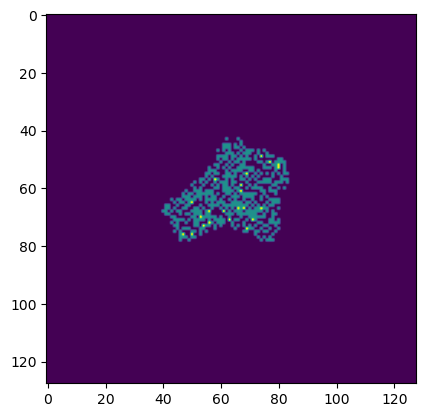

In [107]:
import matplotlib.pyplot as plt
plt.imshow(grid.numpy()[64])

New Job: Make the cfd loss work without the tf gradients

Process:
1. get the edges and edge lengths
2. calculate the finite differences across each edge and store at the edge centroid 
3. get the nodal derivatives by propagating the edge FDs with inverse distance weighting




Tasks:
1. spatial finite differences
2. temporal finite differences
3. main calculator

CONCLUSION: Go back to autograds because each physical system is too complicated lols 

1. gather coordinates of connected nodes using tf.where and tf.gather 
2. do a row-wise subtraction to get the nodal distances 

In [15]:
import numpy as np
import tensorflow as tf

In [ ]:
def compute_spatial_derivatives(coords, features, adj):
    N = adj.shape[0]
    n_features = features.shape[-1]

    ids = tf.cast(tf.where(adj), dtype=tf.int64)
    node_coords = tf.gather(coords, ids[:,0], axis=0)
    neighbour_coords = tf.gather(coords, ids[:,1], axis=0)
    distances = node_coords - neighbour_coords
    inverse_distances = 1 / (tf.linalg.norm(distances, axis=-1) + 1e-8)
    sum_distances = tf.scatter_nd(ids[:, 0:1], inverse_distances, shape=(adj.shape[0],))
    neighbour_weights = inverse_distances / tf.gather(sum_distances, ids[:,0], axis=0)


    node_features = tf.gather(features, ids[:,0], axis=0)
    neighbour_features = tf.gather(features, ids[:,1], axis=0)
    feature_delta = node_features - neighbour_features

    feature_derivatives = feature_delta[:,:,tf.newaxis] / (distances[:,tf.newaxis,:] + 1e-8)
    feature_derivatives = neighbour_weights[:, tf.newaxis, tf.newaxis] * feature_derivatives
    derivatives = tf.scatter_nd(ids[:,0:1], feature_derivatives, shape=(N,n_features, 3))
    return derivatives



adj = np.array([[0, 1, 1], [1, 0,1], [0,1,0]])
coords = np.array([[1,2,3], [4,5,6], [7,8,9]], dtype=np.float32)

features = np.array([[1,2,3,4], [4,5,6,7], [7,8,9,10]], dtype=np.float32)
N = adj.shape[0]
n_features = features.shape[-1]

ids = tf.cast(tf.where(adj), dtype=tf.int64)
node_coords = tf.gather(coords, ids[:,0], axis=0)
neighbour_coords = tf.gather(coords, ids[:,1], axis=0)
distances = node_coords - neighbour_coords
inverse_distances = 1 / (tf.linalg.norm(distances, axis=-1) + 1e-8)
sum_distances = tf.scatter_nd(ids[:, 0:1], inverse_distances, shape=(adj.shape[0],))
neighbour_weights = inverse_distances / tf.gather(sum_distances, ids[:,0], axis=0)


node_features = tf.gather(features, ids[:,0], axis=0)
neighbour_features = tf.gather(features, ids[:,1], axis=0)
feature_delta = node_features - neighbour_features

# Now we have an Nx3 distance matrix and an Nx4 feature matrix and we want to get an Nx3x4 matrix 
feature_derivatives = feature_delta[:,:,tf.newaxis] / (distances[:,tf.newaxis,:] + 1e-8)
feature_derivatives = neighbour_weights[:, tf.newaxis, tf.newaxis] * feature_derivatives
first_differences = tf.scatter_nd(ids[:,0:1], feature_derivatives, shape=(N,n_features, 3))


tf.Tensor(
[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]], shape=(5, 4, 3), dtype=float32)


<tf.Tensor: shape=(3, 4, 3), dtype=float32, numpy=
array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]], dtype=float32)>

In [ ]:
edges = np.argwhere(np.triu(adj, k=1) > 0)
edge_centroids = (coords[edges[:,0]] + coords[edges[:,1]])/2
distances = 


[[    0     1]
 [    0     2]
 [    0  1831]
 ...
 [10975 10976]
 [10977 10985]
 [10981 10986]]
75938


In [2]:
import pyvista as pv
import numpy as np
import tensorflow as tf

In [5]:
mesh = pv.read('test_data/clipped_template-0320.vtu')
coords = np.array(mesh.points)
cell_entity_ids_to_extract = np.where(mesh['CellEntityIds'] == 0)[0]
adj= vtu_adjacency(mesh.extract_cells(cell_entity_ids_to_extract))
print(adj.shape)

features = np.array([mesh.point_data[name] for name in ['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']]).T
print(coords.shape, features.shape)

(10987, 10987)
(10987, 3) (10987, 4)


In [ ]:

def get_cell_adjacency(faces):
    M = faces.shape[0]

    # 1. Canonicalize faces (order-independent)
    faces_sorted = np.sort(faces, axis=-1)      # (M, 4, 3)

    # 2. Flatten faces and track owning cell
    faces_flat = faces_sorted.reshape(-1, 3)    # (M*4, 3)
    cell_ids = np.repeat(np.arange(M), 4)       # (M*4,)

    # 3. Find identical faces
    # Convert faces to a structured array so np.unique works row-wise
    faces_view = faces_flat.view(
        np.dtype((np.void, faces_flat.dtype.itemsize * faces_flat.shape[1]))
    )

    unique_faces, inverse, counts = np.unique(
        faces_view, return_inverse=True, return_counts=True
    )

    # 4. Build adjacency matrix
    adj = np.zeros((M, M), dtype=np.int8)

    # Faces shared by exactly two cells create adjacency
    shared_face_indices = np.where(counts == 2)[0]

    for face_idx in shared_face_indices:
        face_occurrences = np.where(inverse == face_idx)[0]
        c1, c2 = cell_ids[face_occurrences]
        adj[c1, c2] = 1
        adj[c2, c1] = 1
    
    return adj 





In [47]:
mesh.cell_neighbors(23352, 'faces')

[11728, 2, 18867, 46589]

In [ ]:
cells = mesh.extract_cells(cell_entity_ids_to_extract).cells.reshape(-1, 5)[:, 1:]


[1780 1226 1227 4868]
[4332 6324 2889 7169]


### Finite volume attempt

1. find cell centroids
2. compute distance weights between centroid and nodes
3. interpolate node values to centroids
4. find face centroids
5. interpolate node values onto face centroids 
6. compute vector area of sides 
7. get all elements of equation 
8. compute residual


coords - (N,3)
features - (N,4)
cells - (M, 4)
faces - (M, 4, 3)
cell_centroids - (M,3)
face_centroids - (M, 4, 3)

In [ ]:
# coords - (M, 4, 3)
# features - (M,4,4)
# axis - 1
def interpolate_to_centroid(coords, features, ids):
    coords = tf.cast(tf.gather(coords, ids, axis=0), dtype=tf.float32)
    features = tf.cast(tf.gather(features, ids, axis=0), dtype=tf.float32)

    centroids = tf.reduce_mean(coords, axis=-2, keepdims=True) # (M, 1, 3)

    inverse_distances = 1/tf.linalg.norm(coords - centroids, axis=-1, keepdims=True) # (M, 4, 1)
    sum_inv_dist = tf.reduce_sum(inverse_distances, axis=-2, keepdims=True) # (M,1,1)
    weights = inverse_distances/(sum_inv_dist+1e-8) # (M,4,1)

    centroid_features = tf.reduce_sum(features*weights, axis=-2)

    return centroids, centroid_features

# coords - (M, n_faces, n_face_nodes, n_spatial_dims)
def compute_triangle_areas(coords, ids, axis):
    coords = tf.cast(tf.gather(coords, ids, axis=0), dtype=tf.float32)
    side1 = tf.gather(coords, [1], axis=axis) - tf.gather(coords, [0], axis=axis)
    side2 = tf.gather(coords, [2], axis=axis) - tf.gather(coords, [0], axis=axis)

    areas = 0.5 * tf.linalg.cross(side1, side2)

    return areas

In [62]:
cells = tf.convert_to_tensor(mesh.extract_cells(cell_entity_ids_to_extract).cells.reshape(-1, 5)[:, 1:])
faces = tf.gather(cells, [[0,1,2],[0,1,3], [0,2,3],[1,2,3]], axis=-1)
cell_adj = tf.convert_to_tensor(get_cell_adjacency(faces), dtype=tf.float32)

In [65]:
cell_centroids, cell_centroid_features = interpolate_to_centroid(coords, features, cells)
face_centroids, face_centroid_features = interpolate_to_centroid(coords, features, faces)

face_areas = compute_triangle_areas(coords, faces, axis=-2)

continuity = tf.reduce_sum(
                    tf.reduce_sum(
                        tf.gather(face_centroid_features, indices=[1,2,3], axis=-1) * tf.squeeze(face_areas), 
                        axis=-1), 
                    axis=-1)




(62975, 4, 1, 3)
(62975, 4, 1, 3)


<tf.Tensor: shape=(), dtype=float32, numpy=0.39058512>

In [60]:
print(face_centroid_features.shape)
print(face_areas.shape)

(62975, 4, 4)
(62975, 4, 1, 3)
